# Fourier Transform Example: Decomposing a Complex Seasonal Pattern

| Key              | Value                                                                                                                                                                                                                                                                                                            |
|:-----------------|:-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **Course Codes** | BBT 4206 and BFS 4102                                                                                                                                                                                                                                                                                            |
| **Course Names** | BBT 4206: Business Intelligence II (Week 7-9 of 13)<br>BFS 4102: Advanced Business Data Analytics (Week 7-9 of 13)                                                                                                                                                                                               |
| **Semester**     | January to April 2026                                                                                                                                                                                                                                                                                          |
| **Lecturer**     | Allan Omondi                                                                                                                                                                                                                                                                                                     |
| **Contact**      | aomondi@strathmore.edu                                                                                                                                                                                                                                                                                           |
| **Note**         | The lecture contains both theory and practice.<br/>This notebook forms part of the practice.<br/>It is intended for educational purposes only.<br/>Recommended citation: [BibTex](https://raw.githubusercontent.com/course-files/TimeSeriesForecastingandNeuralNetworks/refs/heads/main/RecommendedCitation.bib) |


- The Fourier Transform is a powerful mathematical tool used to analyze the frequency components of signals. In this example, we demonstrate how a complex seasonal pattern can be decomposed into simpler sine waves using the Fourier Transform.
    - We create a synthetic signal that combines multiple sine waves of different frequencies and amplitudes to simulate a complex seasonal pattern. We then visualize the individual components and their sum.
    - The individual components can be used to reconstruct the original signal. The sum of the individual components is the original signal.

    
**Remote Environments:**

Do your best to setup your local environment as guided during the lab, however, if you have challenges setting it up, then you can use the following remote environments temporarily for the lab:<br/>

[![Colab](https://img.shields.io/badge/Open-Colab-orange?logo=googlecolab)](
https://colab.research.google.com/github/course-files/TimeSeriesForecastingandNeuralNetworks/blob/main/4_fourier_transform.ipynb) (preferred option)

[![Codespaces](https://img.shields.io/badge/Open-Codespaces-blue?logo=github)](
https://github.com/codespaces/new/course-files/TimeSeriesForecastingandNeuralNetworks) (alternative)

## Step 1: Install Dependencies and Import Required Libraries

Confirm the following:
1. Which Python interpreter will be used to execute new code and where it is located
2. The Python version

Then install all the packages into the Jupyter notebook's virtual environment before importing them.

In [8]:
import sys
sys.executable

'c:\\Users\\aomondi\\Documents\\GitHub\\Teaching\\TimeSeriesForecastingandNeuralNetworks\\.venv_312\\Scripts\\python.exe'

In [9]:
!python --version

Python 3.12.10


In [10]:
!python -m pip install --upgrade pip

### Set the Environment Variables - Option 1 (Using Python)

In [11]:
%pip install python-dotenv

Note: you may need to restart the kernel to use updated packages.


In [12]:
import sys
import os
from dotenv import load_dotenv

# This loads .env from current or parent directories if present
# For a classroom setup, `override=True` ensures .env values take precedence
# over any existing environment variables
load_dotenv(override=True)

def resolve_environment():
    if os.environ.get("ENVIRONMENT"):
        return os.environ["ENVIRONMENT"].upper()

    # Automatic detection if running in Google Colab
    if "google.colab" in sys.modules:
        return "COLAB"

    # Defaults to a 'DEV' environment
    return "DEV"

ENV_SETUP = resolve_environment()

VALID_ENVIRONMENTS = {"PROD", "STAGING", "TESTING", "COLAB", "DEV"}

if ENV_SETUP not in VALID_ENVIRONMENTS:
    print(f"Warning: Invalid ENVIRONMENT '{ENV_SETUP}'. Defaulting to 'DEV'.")
    ENV_SETUP = "DEV"
print(f"Dependencies will be installed for a '{ENV_SETUP}' environment.")

Dependencies will be installed for a 'DEV' environment.


In [13]:
import subprocess

def silent_pip_install(cmd):
    result = subprocess.run(cmd, shell=True, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
    if result.returncode != 0:
        print(result.stderr.decode())

if ENV_SETUP == "PROD":
    silent_pip_install("pip install -r " \
    "https://raw.githubusercontent.com/course-files/TimeSeriesForecastingandNeuralNetworks/refs/heads/main/requirements/prod.txt")
    print(f"Completed installation of environment dependencies for '{ENV_SETUP}'.")

elif ENV_SETUP in {"STAGING"}:
    silent_pip_install("pip install -r " \
    "https://raw.githubusercontent.com/course-files/TimeSeriesForecastingandNeuralNetworks/refs/heads/main/requirements/dev.txt " \
    "-c https://raw.githubusercontent.com/course-files/TimeSeriesForecastingandNeuralNetworks/refs/heads/main/requirements/constraints.txt")
    print(f"Completed installation of environment dependencies for '{ENV_SETUP}'.")

elif ENV_SETUP in {"TESTING"}:
    silent_pip_install("pip install -r " \
    "https://raw.githubusercontent.com/course-files/TimeSeriesForecastingandNeuralNetworks/refs/heads/main/requirements/dev.txt " \
    "-c https://raw.githubusercontent.com/course-files/TimeSeriesForecastingandNeuralNetworks/refs/heads/main/requirements/constraints.txt")
    print(f"Completed installation of environment dependencies for '{ENV_SETUP}'.")

elif ENV_SETUP in {"COLAB"}:
    silent_pip_install("pip install -r " \
    "https://raw.githubusercontent.com/course-files/TimeSeriesForecastingandNeuralNetworks/refs/heads/main/requirements/colab.txt")
    print(f"Completed installation of environment dependencies for '{ENV_SETUP}'.")

elif ENV_SETUP in {"DEV"}:
    silent_pip_install("pip install -r " \
    "https://raw.githubusercontent.com/course-files/TimeSeriesForecastingandNeuralNetworks/refs/heads/main/requirements/dev.txt " \
    "-c https://raw.githubusercontent.com/course-files/TimeSeriesForecastingandNeuralNetworks/refs/heads/main/requirements/constraints.txt")
    print(f"Completed installation of environment dependencies for '{ENV_SETUP}'.")

Completed installation of environment dependencies for 'DEV'.


### Set the Environment Variables - Option 2 (Manually)

Set the environment by executing one of the following depending on your OS and shell:

For Linux/MacOS Terminal (bash, zsh):
```shell
export ENVIRONMENT=DEV
echo $ENVIRONMENT
```

For Windows Git Bash Terminal:
```shell
export ENVIRONMENT=DEV
echo $ENVIRONMENT
```

For Windows CMD:

```shell
set ENVIRONMENT=DEV
echo %ENVIRONMENT%
```

For Windows PowerShell:
```shell
$env:ENVIRONMENT="DEV"
$env:ENVIRONMENT
```

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Time axis
t = np.linspace(0, 2*np.pi, 500)

# Define "complex" signal as sum of waves
long_wave = np.sin(t)                     # slow yearly cycle
medium_wave = 0.5 * np.sin(4*t)           # monthly cycle
short_wave = 0.2 * np.sin(10*t)           # weekly cycle
complex_signal = long_wave + medium_wave + short_wave

In [15]:
print(t)

[0.         0.01259155 0.02518311 0.03777466 0.05036621 0.06295777
 0.07554932 0.08814088 0.10073243 0.11332398 0.12591554 0.13850709
 0.15109864 0.1636902  0.17628175 0.18887331 0.20146486 0.21405641
 0.22664797 0.23923952 0.25183107 0.26442263 0.27701418 0.28960574
 0.30219729 0.31478884 0.3273804  0.33997195 0.3525635  0.36515506
 0.37774661 0.39033817 0.40292972 0.41552127 0.42811283 0.44070438
 0.45329593 0.46588749 0.47847904 0.4910706  0.50366215 0.5162537
 0.52884526 0.54143681 0.55402836 0.56661992 0.57921147 0.59180302
 0.60439458 0.61698613 0.62957769 0.64216924 0.65476079 0.66735235
 0.6799439  0.69253545 0.70512701 0.71771856 0.73031012 0.74290167
 0.75549322 0.76808478 0.78067633 0.79326788 0.80585944 0.81845099
 0.83104255 0.8436341  0.85622565 0.86881721 0.88140876 0.89400031
 0.90659187 0.91918342 0.93177498 0.94436653 0.95695808 0.96954964
 0.98214119 0.99473274 1.0073243  1.01991585 1.03250741 1.04509896
 1.05769051 1.07028207 1.08287362 1.09546517 1.10805673 1.12064

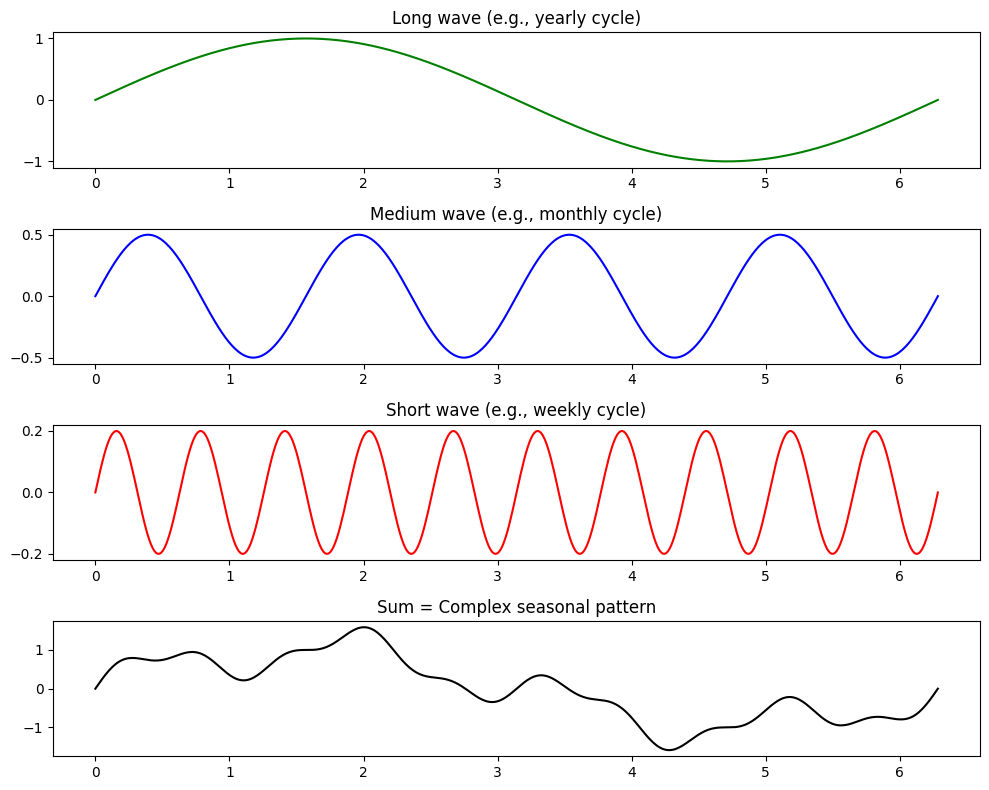

In [16]:
# Plot decomposition
plt.figure(figsize=(10, 8))

plt.subplot(4,1,1)
plt.plot(t, long_wave, 'g')
plt.title("Long wave (e.g., yearly cycle)")

plt.subplot(4,1,2)
plt.plot(t, medium_wave, 'b')
plt.title("Medium wave (e.g., monthly cycle)")

plt.subplot(4,1,3)
plt.plot(t, short_wave, 'r')
plt.title("Short wave (e.g., weekly cycle)")

plt.subplot(4,1,4)
plt.plot(t, complex_signal, 'k')
plt.title("Sum = Complex seasonal pattern")

plt.tight_layout()
plt.show()